# Course Project N.03: Clinical Records
**authors:** Vojtěch Tichý, Sávio Campos de Souza <br>
https://www.overleaf.com/3315726454qptfqhmwhcpy#04e0ee

In [110]:
%pip install -q numpy pandas matplotlib seaborn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


Note: you may need to restart the kernel to use updated packages.


In [111]:
df = pd.read_csv('03_ClinicalRecords_Clustering/20_Clinical Records/diabetic_data.csv')
ids_df = pd.read_csv('03_ClinicalRecords_Clustering/20_Clinical Records/IDs_mapping.csv')

df

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,443847548,100162476,AfricanAmerican,Male,[70-80),?,1,3,7,3,...,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,443847782,74694222,AfricanAmerican,Female,[80-90),?,1,4,5,5,...,No,Steady,No,No,No,No,No,No,Yes,NO
101763,443854148,41088789,Caucasian,Male,[70-80),?,1,1,7,1,...,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,443857166,31693671,Caucasian,Female,[80-90),?,2,3,7,10,...,No,Up,No,No,No,No,No,Ch,Yes,NO


In [112]:
ids_df

,admission_type_id,description
0,1,Emergency
1,2,Urgent
2,3,Elective
3,4,Newborn
4,5,Not Available
...,...,...
62,22,Transfer from hospital inpt/same fac reslt in...
63,23,Born inside this hospital
64,24,Born outside this hospital
65,25,Transfer from Ambulatory Surgery Center


## Exploratory analysis
First we look at the categorical attributes.

In [113]:

def plot_numerical_cols(df: pd.DataFrame) -> None:
	"""
	@brief

	@param df
	@return
	"""
	
	numerical_cols = df.select_dtypes(include=['int', 'float']).columns
	plot_size = len(numerical_cols) // 4
	fig, axes = plt.subplots(plot_size, plot_size, figsize=(12,10))
	axes = axes.flatten()

	for ax in axes:
		pass


def plot_categorical_cols(df: pd.DataFrame, col_cnt: int = 4) -> None:
	"""
	@brief

	@param df
	@return
	"""
	
	categorical_cols = df.select_dtypes(include=['str', 'category']).columns
	
	fig, axes = plt.subplots(len(categorical_cols) // 4 + 1, col_cnt, figsize=(16,20))
	axes = axes.flatten()

	for i, col in enumerate(categorical_cols):
		sns.countplot(data=df, x=col, ax=axes[i])
		axes[i].set_ylabel("")
		axes[i].set_xlabel(col, fontsize=16)
	
	# to hide excess subplot axes 
	for i in range(len(categorical_cols), len(axes)):
		axes[i].set_visible(False)

	fig.supylabel('Count', fontsize=20)
	plt.suptitle('Coutplots of categorical attributes', fontsize=24, y=1)
	plt.tight_layout()
	plt.show()


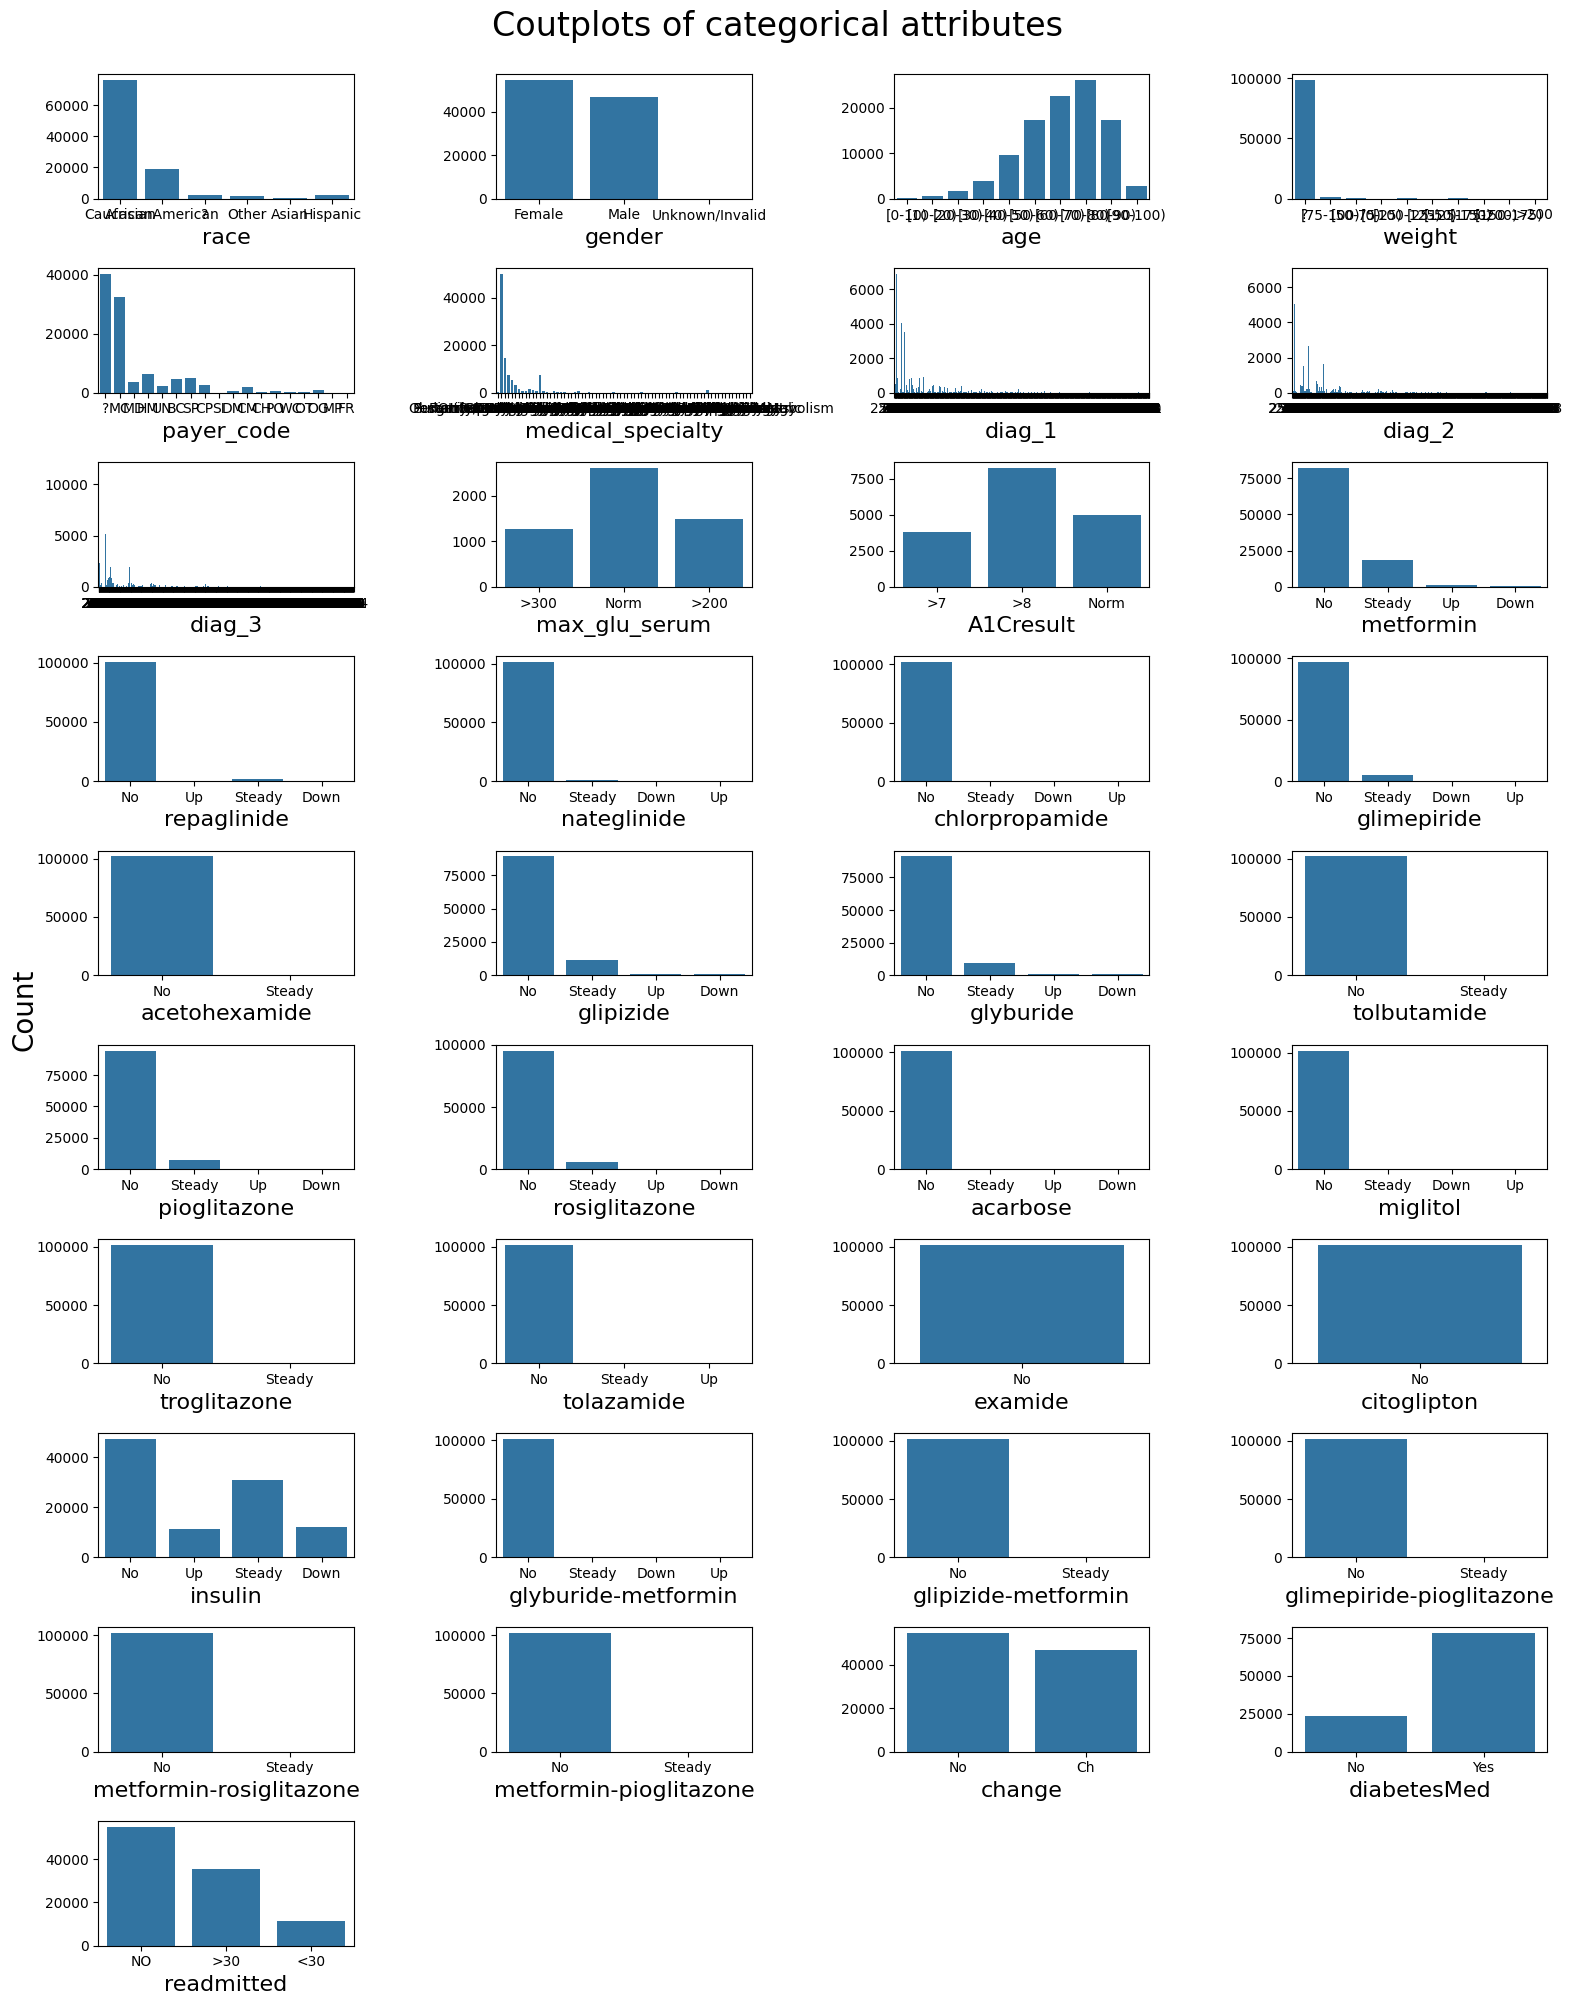

In [114]:
plot_categorical_cols(df)


From the graphs we can clearly see attributes, which have one values in all rows. These columns we can drop, since they do not bring any value.

In [116]:
columns_to_drop = []

for col in df.columns:
    if len(df[col].unique()) <= 1:
        columns_to_drop.append(col)

df.drop(columns=columns_to_drop, inplace=True)
print(f"{len(columns_to_drop)} columns are dropped: {columns_to_drop}")

2 columns are dropped: ['examide', 'citoglipton']
